In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report,
                              roc_curve)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42


In [2]:
df = pd.read_csv('ticket_fraud_dataset_2020_2024.csv', parse_dates=['date'])
df = df.sort_values(['date', 'time']).reset_index(drop=True)
print('Shape:', df.shape)
df.head()


Shape: (9800, 18)


,transaction_id,passenger_id,passenger_name,date,time,day_of_week,route,travel_class,ticket_type,standard_fare_lkr,fare_paid_lkr,payment_method,booking_channel,seat_number,ticket_scan_count,inspection_status,is_fraud,fraud_type
0,TXN100005,PSG100073,Kamal Bandara,2020-01-01,07:37,Wednesday,Maradana - Puttalam,3rd Class,Full Fare,180,180,Cash,Station Counter,NaN,1,Inspected,0,NaN
1,TXN100002,PSG102652,Ashan de Zoysa,2020-01-01,08:12,Wednesday,Colombo Fort - Batticaloa,3rd Class,Student Concession,180,72,Cash,Station Counter,NaN,1,Not Inspected,0,NaN
2,TXN100004,PSG101957,Malsha Fernando,2020-01-01,08:43,Wednesday,Colombo Fort - Vavuniya,3rd Class,Full Fare,180,180,Online,Online,118.0,1,Not Inspected,0,NaN
3,TXN100001,PSG102132,Sithumini Rajapaksha,2020-01-01,09:39,Wednesday,Colombo Fort - Batticaloa,3rd Class,Student Concession,180,72,Cash,Station Counter,NaN,1,Not Inspected,0,NaN
4,TXN100003,PSG100387,Sanduni Rajapaksha,2020-01-01,15:05,Wednesday,Colombo Fort - Vavuniya,2nd Class,Full Fare,420,420,Cash,Station Counter,NaN,1,Not Inspected,0,NaN


In [3]:
print('Date range:', df['date'].min().date(), '->', df['date'].max().date())
print('\nFraud label distribution:')
print(df['is_fraud'].value_counts())
print('Overall fraud rate: {:.2%}'.format(df['is_fraud'].mean()))
print('\nFraud type distribution:')
print(df['fraud_type'].value_counts())


Date range: 2020-01-01 -> 2024-12-31

Fraud label distribution:
is_fraud
0    8974
1     826
Name: count, dtype: int64
Overall fraud rate: 8.43%

Fraud type distribution:
fraud_type
Ticket Reuse                 300
Suspicious Resale            276
Abnormal Concession Usage    250
Name: count, dtype: int64


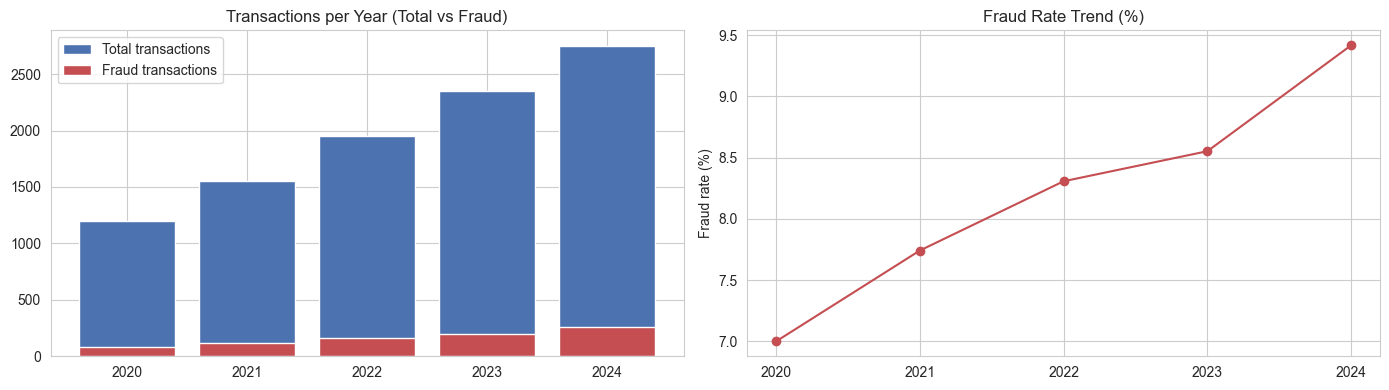

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

yearly = df.groupby(df['date'].dt.year)['is_fraud'].agg(['count', 'sum', 'mean'])
axes[0].bar(yearly.index.astype(str), yearly['count'], color='#4C72B0', label='Total transactions')
axes[0].bar(yearly.index.astype(str), yearly['sum'], color='#C44E52', label='Fraud transactions')
axes[0].set_title('Transactions per Year (Total vs Fraud)')
axes[0].legend()

axes[1].plot(yearly.index.astype(str), yearly['mean'] * 100, marker='o', color='#C44E52')
axes[1].set_title('Fraud Rate Trend (%)')
axes[1].set_ylabel('Fraud rate (%)')

plt.tight_layout()
plt.show()


In [5]:
data = df.copy()

# --- behavioural: fare / concession deviation -----------------------------
official_ratio = {
    'Full Fare': 1.0, 'Season Ticket': 0.5, 'Student Concession': 0.4,
    'Senior Citizen Concession': 0.5, 'Government Employee Concession': 0.6,
    'Disability Concession': 0.3,
}
data['expected_ratio'] = data['ticket_type'].map(official_ratio)
data['paid_ratio'] = data['fare_paid_lkr'] / data['standard_fare_lkr']
data['ratio_deviation'] = (data['paid_ratio'] - data['expected_ratio']).abs()

# --- behavioural: ticket reuse ---------------------------------------------
data['multi_scan_flag'] = (data['ticket_scan_count'] > 1).astype(int)

# --- behavioural: online booking with missing seat (resale signal) --------
data['is_online'] = (data['booking_channel'] == 'Online').astype(int)
data['online_missing_seat'] = ((data['is_online'] == 1) & (data['seat_number'].isna())).astype(int)

# --- temporal ----------------------------------------------------------------
data['hour'] = data['time'].str.split(':').str[0].astype(int)
data['is_night'] = ((data['hour'] < 6) | (data['hour'] >= 19)).astype(int)
data['is_weekend'] = data['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

# --- behavioural: passenger history (causal / time-ordered, no leakage) ----
data = data.sort_values(['passenger_id', 'date']).reset_index(drop=True)
data['passenger_txn_number'] = data.groupby('passenger_id').cumcount() + 1
data['passenger_prior_fraud_count'] = (
    data.groupby('passenger_id')['is_fraud'].cumsum() - data['is_fraud']
)
data['passenger_prior_fraud_rate'] = (
    data['passenger_prior_fraud_count'] / (data['passenger_txn_number'] - 1)
).fillna(0)

data = data.sort_values(['date', 'time']).reset_index(drop=True)
data[['ratio_deviation', 'multi_scan_flag', 'online_missing_seat', 'is_night',
      'is_weekend', 'passenger_prior_fraud_count']].describe()


,ratio_deviation,multi_scan_flag,online_missing_seat,is_night,is_weekend,passenger_prior_fraud_count
count,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000
mean,0.001959,0.030612,0.021429,0.124592,0.292245,0.236531
std,0.012747,0.172274,0.144815,0.330272,0.454817,0.585546
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,0.100000,1.000000,1.000000,1.000000,1.000000,5.000000


In [6]:
# --- contextual: categorical encoding ---------------------------------------
cat_cols = ['travel_class', 'ticket_type', 'payment_method', 'booking_channel']
data_enc = pd.get_dummies(data, columns=cat_cols, drop_first=False)

# route: frequency-encode (14 routes -> avoid huge one-hot for a tree/SVM model)
route_freq = data['route'].value_counts(normalize=True)
data_enc['route_freq'] = data['route'].map(route_freq)

FEATURE_COLS = [
    'ratio_deviation', 'multi_scan_flag', 'online_missing_seat',
    'hour', 'is_night', 'is_weekend',
    'passenger_prior_fraud_count', 'passenger_prior_fraud_rate', 'passenger_txn_number',
    'route_freq',
] + [c for c in data_enc.columns if c.startswith(('travel_class_', 'ticket_type_',
                                                     'payment_method_', 'booking_channel_'))]

print(f'{len(FEATURE_COLS)} features used:')
print(FEATURE_COLS)

X_full = data_enc[FEATURE_COLS].astype(float)
y_full = data_enc['is_fraud'].astype(int)


23 features used:
['ratio_deviation', 'multi_scan_flag', 'online_missing_seat', 'hour', 'is_night', 'is_weekend', 'passenger_prior_fraud_count', 'passenger_prior_fraud_rate', 'passenger_txn_number', 'route_freq', 'travel_class_1st Class', 'travel_class_2nd Class', 'travel_class_3rd Class', 'ticket_type_Disability Concession', 'ticket_type_Full Fare', 'ticket_type_Government Employee Concession', 'ticket_type_Season Ticket', 'ticket_type_Senior Citizen Concession', 'ticket_type_Student Concession', 'payment_method_Cash', 'payment_method_Online', 'booking_channel_Online', 'booking_channel_Station Counter']


In [7]:
train_mask = data_enc['date'].dt.year <= 2023
test_mask = data_enc['date'].dt.year == 2024

X_train, X_test = X_full[train_mask], X_full[test_mask]
y_train, y_test = y_full[train_mask], y_full[test_mask]

print('Train:', X_train.shape, ' Fraud rate:', y_train.mean().round(4))
print('Test :', X_test.shape, ' Fraud rate:', y_test.mean().round(4))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

contamination = float(y_train.mean())
print('Contamination (fraud rate) used for the anomaly models:', round(contamination, 4))


Train: (7050, 23)  Fraud rate: 0.0804
Test : (2750, 23)  Fraud rate: 0.0942
Contamination (fraud rate) used for the anomaly models: 0.0804


In [8]:
iso_forest = IsolationForest(
    n_estimators=300,
    contamination=contamination,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
iso_forest.fit(X_train_scaled)

# score_samples: higher = more normal. We flip sign so higher = more anomalous.
iso_scores_test = -iso_forest.score_samples(X_test_scaled)
iso_pred_test = (iso_forest.predict(X_test_scaled) == -1).astype(int)

print('Isolation Forest trained.')


Isolation Forest trained.


In [9]:
X_train_normal_scaled = X_train_scaled[y_train.values == 0]

ocsvm = OneClassSVM(kernel='rbf', nu=max(contamination, 0.01), gamma='scale')
ocsvm.fit(X_train_normal_scaled)

ocsvm_scores_test = -ocsvm.decision_function(X_test_scaled)   # higher = more anomalous
ocsvm_pred_test = (ocsvm.predict(X_test_scaled) == -1).astype(int)

print('One-Class SVM trained on', X_train_normal_scaled.shape[0], 'normal transactions.')


One-Class SVM trained on 6483 normal transactions.


In [10]:
n_features = X_train_scaled.shape[1]
bottleneck = max(2, n_features // 3)

autoencoder = MLPRegressor(
    hidden_layer_sizes=(16, bottleneck, 16),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=RANDOM_STATE,
    early_stopping=True,
    n_iter_no_change=15,
)
autoencoder.fit(X_train_normal_scaled, X_train_normal_scaled)

def reconstruction_error(model, X):
    X_hat = model.predict(X)
    return np.mean((X - X_hat) ** 2, axis=1)

ae_scores_test = reconstruction_error(autoencoder, X_test_scaled)
ae_threshold = np.quantile(reconstruction_error(autoencoder, X_train_normal_scaled), 1 - contamination)
ae_pred_test = (ae_scores_test > ae_threshold).astype(int)

print('Autoencoder trained. Reconstruction-error threshold:', round(ae_threshold, 4))


Autoencoder trained. Reconstruction-error threshold: 0.3613


In [11]:
def evaluate(name, y_true, y_pred, y_score):
    return {
        'Model': name,
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-score': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_score),
    }

results = pd.DataFrame([
    evaluate('Isolation Forest', y_test, iso_pred_test, iso_scores_test),
    evaluate('One-Class SVM', y_test, ocsvm_pred_test, ocsvm_scores_test),
    evaluate('Autoencoder', y_test, ae_pred_test, ae_scores_test),
])
results = results.set_index('Model').round(3)
results


,Precision,Recall,F1-score,ROC-AUC
Model,,,,
Isolation Forest,0.287,0.502,0.365,0.812
One-Class SVM,0.311,0.938,0.467,0.958
Autoencoder,0.312,0.942,0.469,0.959


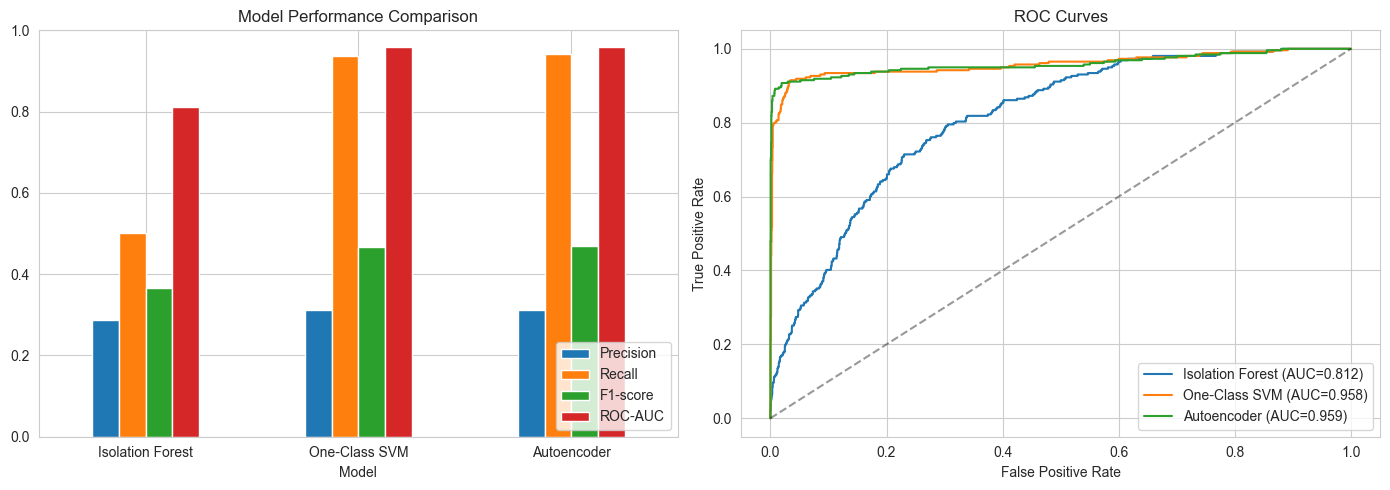

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results[['Precision', 'Recall', 'F1-score', 'ROC-AUC']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Model Performance Comparison')
axes[0].set_ylim(0, 1)
axes[0].legend(loc='lower right')
axes[0].tick_params(axis='x', rotation=0)

for name, scores in [('Isolation Forest', iso_scores_test),
                      ('One-Class SVM', ocsvm_scores_test),
                      ('Autoencoder', ae_scores_test)]:
    fpr, tpr, _ = roc_curve(y_test, scores)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, scores):.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves')
axes[1].legend()

plt.tight_layout()
plt.show()


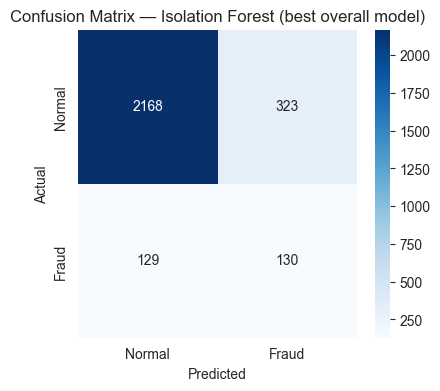

              precision    recall  f1-score   support

      Normal       0.94      0.87      0.91      2491
       Fraud       0.29      0.50      0.37       259

    accuracy                           0.84      2750
   macro avg       0.62      0.69      0.64      2750
weighted avg       0.88      0.84      0.85      2750



In [13]:
cm = confusion_matrix(y_test, iso_pred_test)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title('Confusion Matrix — Isolation Forest (best overall model)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(classification_report(y_test, iso_pred_test, target_names=['Normal', 'Fraud']))


In [14]:
iso_scores_train = -iso_forest.score_samples(X_train_scaled)
ocsvm_scores_train = -ocsvm.decision_function(X_train_scaled)
ae_scores_train = reconstruction_error(autoencoder, X_train_scaled)

score_bounds = {
    'iso': (iso_scores_train.min(), iso_scores_train.max()),
    'ocsvm': (ocsvm_scores_train.min(), ocsvm_scores_train.max()),
    'ae': (ae_scores_train.min(), ae_scores_train.max()),
}

def normalize(score, bounds):
    lo, hi = bounds
    return np.clip((score - lo) / (hi - lo + 1e-9), 0, 1)

def combined_risk_score(iso_s, ocsvm_s, ae_s):
    n_iso = normalize(iso_s, score_bounds['iso'])
    n_ocsvm = normalize(ocsvm_s, score_bounds['ocsvm'])
    n_ae = normalize(ae_s, score_bounds['ae'])
    return np.round(100 * (n_iso + n_ocsvm + n_ae) / 3, 1)

risk_score_test = combined_risk_score(iso_scores_test, ocsvm_scores_test, ae_scores_test)

def risk_category(score):
    if score >= 66:
        return 'High'
    elif score >= 40:
        return 'Medium'
    return 'Low'

def flag_reason(row):
    reasons = []
    if row['multi_scan_flag'] == 1:
        reasons.append('Ticket scanned multiple times (possible reuse)')
    if row['online_missing_seat'] == 1:
        reasons.append('Online booking with no assigned seat (possible resale)')
    if row['ratio_deviation'] > 0.03:
        reasons.append('Fare paid does not match official concession rate')
    if row['passenger_prior_fraud_count'] >= 2:
        reasons.append('Passenger has multiple prior fraud incidents')
    if row['is_night'] == 1 and row['ratio_deviation'] > 0:
        reasons.append('Irregular fare during off-peak/night hours')
    return '; '.join(reasons) if reasons else 'No strong rule triggered — flagged by model anomaly score only'

test_results = data.loc[X_test.index, ['transaction_id', 'passenger_id', 'passenger_name',
                                        'date', 'route', 'ticket_type', 'fare_paid_lkr',
                                        'is_fraud', 'fraud_type']].copy()
test_results['risk_score'] = risk_score_test
test_results['risk_category'] = test_results['risk_score'].apply(risk_category)
test_results['reason_for_flagging'] = data.loc[X_test.index].apply(flag_reason, axis=1)
test_results['suspected_fraud_type'] = np.where(
    data.loc[X_test.index, 'multi_scan_flag'] == 1, 'Ticket Reuse',
    np.where(data.loc[X_test.index, 'online_missing_seat'] == 1, 'Suspicious Resale',
             np.where(data.loc[X_test.index, 'ratio_deviation'] > 0.03, 'Abnormal Concession Usage', 'Unclassified')))

test_results.sort_values('risk_score', ascending=False).head(10)


,transaction_id,passenger_id,passenger_name,date,route,ticket_type,fare_paid_lkr,is_fraud,fraud_type,risk_score,risk_category,reason_for_flagging,suspected_fraud_type
9650,TXN109657,PSG102642,Chaminda Senanayake,2024-12-13,Colombo Fort - Kurunegala,Student Concession,285,1,Abnormal Concession Usage,100.0,High,Fare paid does not match official concession r...,Abnormal Concession Usage
8178,TXN108175,PSG102867,Chathurika Senanayake,2024-05-31,Colombo Fort - Batticaloa,Government Employee Concession,90,1,Abnormal Concession Usage,99.7,High,Fare paid does not match official concession r...,Abnormal Concession Usage
9058,TXN109055,PSG102491,Chamara Rathnayake,2024-09-29,Colombo Fort - Kandy,Full Fare,950,1,Suspicious Resale,96.5,High,Online booking with no assigned seat (possible...,Suspicious Resale
9080,TXN109084,PSG100281,Ishara Jayawardena,2024-10-03,Colombo Fort - Matara,Senior Citizen Concession,72,1,Abnormal Concession Usage,96.1,High,Fare paid does not match official concession r...,Abnormal Concession Usage
9329,TXN109334,PSG101331,Ruwan Weerasinghe,2024-11-02,Colombo Fort - Vavuniya,Season Ticket,210,1,Ticket Reuse,95.6,High,Ticket scanned multiple times (possible reuse)...,Ticket Reuse
7371,TXN107368,PSG102364,Saman Ekanayake,2024-02-07,Colombo Fort - Anuradhapura,Season Ticket,210,1,Ticket Reuse,95.1,High,Ticket scanned multiple times (possible reuse)...,Ticket Reuse
7095,TXN107089,PSG102644,Ashan Gunawardena,2024-01-06,Colombo Fort - Trincomalee,Student Concession,285,1,Abnormal Concession Usage,94.5,High,Fare paid does not match official concession r...,Abnormal Concession Usage
8089,TXN108088,PSG101336,Sanduni Jayawardena,2024-05-15,Colombo Fort - Anuradhapura,Student Concession,126,1,Abnormal Concession Usage,93.9,High,Fare paid does not match official concession r...,Abnormal Concession Usage
7985,TXN107993,PSG100497,Nadeesha Amarasinghe,2024-05-02,Colombo Fort - Galle,Full Fare,180,1,Ticket Reuse,92.8,High,Ticket scanned multiple times (possible reuse)...,Ticket Reuse
9271,TXN109271,PSG101592,Dilani Abeywardena,2024-10-27,Colombo Fort - Anuradhapura,Student Concession,380,1,Suspicious Resale,92.4,High,Online booking with no assigned seat (possible...,Suspicious Resale


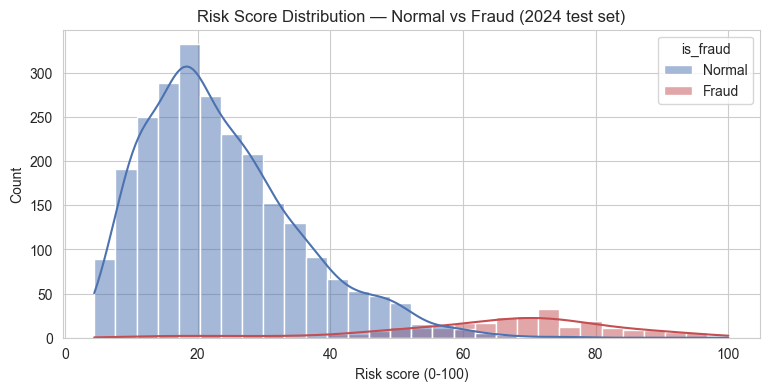

Risk category breakdown:
risk_category
Low       2271
Medium     328
High       151
Name: count, dtype: int64


In [15]:
plt.figure(figsize=(9, 4))
sns.histplot(data=test_results, x='risk_score', hue=test_results['is_fraud'].map({0: 'Normal', 1: 'Fraud'}),
             bins=30, kde=True, palette={'Normal': '#4C72B0', 'Fraud': '#C44E52'})
plt.title('Risk Score Distribution — Normal vs Fraud (2024 test set)')
plt.xlabel('Risk score (0-100)')
plt.show()

print('Risk category breakdown:')
print(test_results['risk_category'].value_counts())


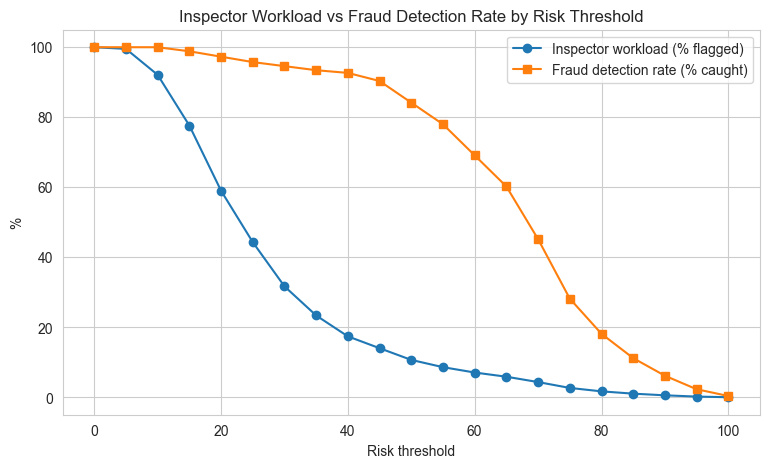

Recommended risk threshold: 45


,threshold,inspection_rate,detection_rate,trade_off
0,0,1.000000,1.000000,0.000000
1,5,0.995273,1.000000,0.004727
2,10,0.921091,1.000000,0.078909
3,15,0.776364,0.988417,0.212053
4,20,0.590182,0.972973,0.382791
5,25,0.443273,0.957529,0.514256
6,30,0.317091,0.945946,0.628855
7,35,0.233818,0.934363,0.700545
8,40,0.174182,0.926641,0.752459
9,45,0.140364,0.903475,0.763111


In [16]:
thresholds = np.arange(0, 101, 5)
workload_curve = []
for t in thresholds:
    flagged = test_results['risk_score'] >= t
    inspection_rate = flagged.mean()
    detection_rate = test_results.loc[test_results['is_fraud'] == 1, 'risk_score'].ge(t).mean()
    workload_curve.append({'threshold': t, 'inspection_rate': inspection_rate, 'detection_rate': detection_rate})

workload_df = pd.DataFrame(workload_curve)

plt.figure(figsize=(9, 5))
plt.plot(workload_df['threshold'], workload_df['inspection_rate'] * 100, marker='o', label='Inspector workload (% flagged)')
plt.plot(workload_df['threshold'], workload_df['detection_rate'] * 100, marker='s', label='Fraud detection rate (% caught)')
plt.xlabel('Risk threshold')
plt.ylabel('%')
plt.title('Inspector Workload vs Fraud Detection Rate by Risk Threshold')
plt.legend()
plt.show()

# recommend a threshold: best trade-off = maximise (detection - workload)
workload_df['trade_off'] = workload_df['detection_rate'] - workload_df['inspection_rate']
recommended_threshold = workload_df.loc[workload_df['trade_off'].idxmax(), 'threshold']
print('Recommended risk threshold:', recommended_threshold)
workload_df


In [17]:
import os
os.makedirs('models', exist_ok=True)

joblib.dump(iso_forest, 'models/isolation_forest.joblib')
joblib.dump(ocsvm, 'models/one_class_svm.joblib')
joblib.dump(autoencoder, 'models/autoencoder.joblib')
joblib.dump(scaler, 'models/scaler.joblib')

artifact_meta = {
    'feature_cols': FEATURE_COLS,
    'official_ratio': official_ratio,
    'score_bounds': {k: [float(v[0]), float(v[1])] for k, v in score_bounds.items()},
    'ae_threshold': float(ae_threshold),
    'recommended_risk_threshold': float(recommended_threshold),
    'route_freq': route_freq.to_dict(),
}
with open('models/artifact_meta.json', 'w') as f:
    json.dump(artifact_meta, f, indent=2)

test_results.to_csv('models/risk_scored_transactions_2024.csv', index=False)

print('Saved to ./models/:')
for f in sorted(os.listdir('models')):
    print(' -', f)


Saved to ./models/:
 - artifact_meta.json
 - autoencoder.joblib
 - isolation_forest.joblib
 - one_class_svm.joblib
 - risk_scored_transactions_2024.csv
 - scaler.joblib


In [18]:
def load_fraud_models(model_dir='models'):
    models = {
        'iso_forest': joblib.load(f'{model_dir}/isolation_forest.joblib'),
        'ocsvm': joblib.load(f'{model_dir}/one_class_svm.joblib'),
        'autoencoder': joblib.load(f'{model_dir}/autoencoder.joblib'),
        'scaler': joblib.load(f'{model_dir}/scaler.joblib'),
    }
    with open(f'{model_dir}/artifact_meta.json') as f:
        models['meta'] = json.load(f)
    return models


def _engineer_features(txn_df, meta, passenger_history=None):
    """txn_df: raw transaction rows with the same raw columns as the training CSV
    (transaction_id, passenger_id, date, time, day_of_week, route, travel_class,
    ticket_type, standard_fare_lkr, fare_paid_lkr, payment_method, booking_channel,
    seat_number, ticket_scan_count).

    passenger_history: optional dict {passenger_id: {'txn_count': int, 'fraud_count': int}}
    giving each passenger's PAST transaction/fraud counts (for the behavioural features).
    If not supplied, new/unknown passengers are treated as first-time travellers.
    """
    d = txn_df.copy()
    official_ratio = meta['official_ratio']

    d['expected_ratio'] = d['ticket_type'].map(official_ratio)
    d['paid_ratio'] = d['fare_paid_lkr'] / d['standard_fare_lkr']
    d['ratio_deviation'] = (d['paid_ratio'] - d['expected_ratio']).abs()

    d['multi_scan_flag'] = (d['ticket_scan_count'] > 1).astype(int)
    d['is_online'] = (d['booking_channel'] == 'Online').astype(int)
    d['online_missing_seat'] = ((d['is_online'] == 1) & (d['seat_number'].isna())).astype(int)

    d['hour'] = d['time'].astype(str).str.split(':').str[0].astype(int)
    d['is_night'] = ((d['hour'] < 6) | (d['hour'] >= 19)).astype(int)
    d['is_weekend'] = d['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

    passenger_history = passenger_history or {}
    d['passenger_txn_number'] = d['passenger_id'].map(
        lambda p: passenger_history.get(p, {}).get('txn_count', 0) + 1)
    d['passenger_prior_fraud_count'] = d['passenger_id'].map(
        lambda p: passenger_history.get(p, {}).get('fraud_count', 0))
    d['passenger_prior_fraud_rate'] = (
        d['passenger_prior_fraud_count'] / (d['passenger_txn_number'] - 1)
    ).replace([np.inf, -np.inf], 0).fillna(0)

    d['route_freq'] = d['route'].map(meta['route_freq']).fillna(min(meta['route_freq'].values()))

    d_enc = pd.get_dummies(d, columns=['travel_class', 'ticket_type', 'payment_method', 'booking_channel'])
    for col in meta['feature_cols']:
        if col not in d_enc.columns:
            d_enc[col] = 0
    X = d_enc[meta['feature_cols']].astype(float)
    return d, X


def predict_fraud_risk(txn_df, model_dir='models', passenger_history=None):
    """Score new transactions and return risk score / category / suspected type / reason."""
    models = load_fraud_models(model_dir)
    meta = models['meta']

    d, X = _engineer_features(txn_df, meta, passenger_history)
    X_scaled = models['scaler'].transform(X)

    iso_s = -models['iso_forest'].score_samples(X_scaled)
    ocsvm_s = -models['ocsvm'].decision_function(X_scaled)
    ae_s = np.mean((X_scaled - models['autoencoder'].predict(X_scaled)) ** 2, axis=1)

    def _norm(score, bounds):
        lo, hi = bounds
        return np.clip((score - lo) / (hi - lo + 1e-9), 0, 1)

    n_iso = _norm(iso_s, meta['score_bounds']['iso'])
    n_ocsvm = _norm(ocsvm_s, meta['score_bounds']['ocsvm'])
    n_ae = _norm(ae_s, meta['score_bounds']['ae'])
    risk_score = np.round(100 * (n_iso + n_ocsvm + n_ae) / 3, 1)

    def _category(s):
        return 'High' if s >= 66 else ('Medium' if s >= 40 else 'Low')

    def _reason(row):
        reasons = []
        if row['multi_scan_flag'] == 1:
            reasons.append('Ticket scanned multiple times (possible reuse)')
        if row['online_missing_seat'] == 1:
            reasons.append('Online booking with no assigned seat (possible resale)')
        if row['ratio_deviation'] > 0.03:
            reasons.append('Fare paid does not match official concession rate')
        if row['passenger_prior_fraud_count'] >= 2:
            reasons.append('Passenger has multiple prior fraud incidents')
        if row['is_night'] == 1 and row['ratio_deviation'] > 0:
            reasons.append('Irregular fare during off-peak/night hours')
        return '; '.join(reasons) if reasons else 'Flagged by model anomaly score only'

    def _suspected_type(row):
        if row['multi_scan_flag'] == 1:
            return 'Ticket Reuse'
        if row['online_missing_seat'] == 1:
            return 'Suspicious Resale'
        if row['ratio_deviation'] > 0.03:
            return 'Abnormal Concession Usage'
        return 'Unclassified'

    out = txn_df.copy()
    out['risk_score'] = risk_score
    out['risk_category'] = [ _category(s) for s in risk_score ]
    out['suspected_fraud_type'] = d.apply(_suspected_type, axis=1).values
    out['reason_for_flagging'] = d.apply(_reason, axis=1).values
    out['recommended_action'] = np.where(
        out['risk_category'] == 'High', 'Priority inspection',
        np.where(out['risk_category'] == 'Medium', 'Random spot-check', 'No action needed'))
    return out

print('predict_fraud_risk() ready.')


predict_fraud_risk() ready.


In [19]:
# ---- Example: score 4 brand-new, unseen transactions ----------------------
new_transactions = pd.DataFrame([
    {  # looks like a clean, normal full-fare trip
        'transaction_id': 'TXN900001', 'passenger_id': 'PSG900001', 'date': '2025-01-15',
        'time': '09:15', 'day_of_week': 'Wednesday', 'route': 'Colombo Fort - Kandy',
        'travel_class': '2nd Class', 'ticket_type': 'Full Fare', 'standard_fare_lkr': 420,
        'fare_paid_lkr': 420, 'payment_method': 'Cash', 'booking_channel': 'Station Counter',
        'seat_number': np.nan, 'ticket_scan_count': 1,
    },
    {  # ticket reuse pattern: scanned 4 times
        'transaction_id': 'TXN900002', 'passenger_id': 'PSG900002', 'date': '2025-01-15',
        'time': '18:40', 'day_of_week': 'Wednesday', 'route': 'Colombo Fort - Jaffna',
        'travel_class': '3rd Class', 'ticket_type': 'Full Fare', 'standard_fare_lkr': 180,
        'fare_paid_lkr': 180, 'payment_method': 'Cash', 'booking_channel': 'Station Counter',
        'seat_number': np.nan, 'ticket_scan_count': 4,
    },
    {  # suspicious resale pattern: online booking, no seat number
        'transaction_id': 'TXN900003', 'passenger_id': 'PSG900003', 'date': '2025-01-16',
        'time': '11:05', 'day_of_week': 'Thursday', 'route': 'Colombo Fort - Negombo (Coastal Line local)',
        'travel_class': '1st Class', 'ticket_type': 'Full Fare', 'standard_fare_lkr': 950,
        'fare_paid_lkr': 950, 'payment_method': 'Online', 'booking_channel': 'Online',
        'seat_number': np.nan, 'ticket_scan_count': 1,
    },
    {  # abnormal concession usage: government employee paying far less than 60% ratio
        'transaction_id': 'TXN900004', 'passenger_id': 'PSG900004', 'date': '2025-01-16',
        'time': '07:50', 'day_of_week': 'Thursday', 'route': 'Colombo Fort - Matara',
        'travel_class': '3rd Class', 'ticket_type': 'Government Employee Concession',
        'standard_fare_lkr': 180, 'fare_paid_lkr': 90, 'payment_method': 'Online',
        'booking_channel': 'Online', 'seat_number': 214.0, 'ticket_scan_count': 1,
    },
])

# example: PSG900002 has 2 prior known fraud incidents on record
passenger_history_example = {
    'PSG900002': {'txn_count': 5, 'fraud_count': 2},
}

scored = predict_fraud_risk(new_transactions, model_dir='models',
                             passenger_history=passenger_history_example)
scored[['transaction_id', 'passenger_id', 'ticket_type', 'risk_score', 'risk_category',
        'suspected_fraud_type', 'reason_for_flagging', 'recommended_action']]


,transaction_id,passenger_id,ticket_type,risk_score,risk_category,suspected_fraud_type,reason_for_flagging,recommended_action
0,TXN900001,PSG900001,Full Fare,16.5,Low,Unclassified,Flagged by model anomaly score only,No action needed
1,TXN900002,PSG900002,Full Fare,71.3,High,Ticket Reuse,Ticket scanned multiple times (possible reuse)...,Priority inspection
2,TXN900003,PSG900003,Full Fare,75.3,High,Suspicious Resale,Online booking with no assigned seat (possible...,Priority inspection
3,TXN900004,PSG900004,Government Employee Concession,76.9,High,Abnormal Concession Usage,Fare paid does not match official concession rate,Priority inspection
